# Pertemuan 12 - Data Science

**Nama:** Krisno Hasmilu Hutabarat  
**NIM:** 240401010102  
**Kelas:** IF401  
**Mata Kuliah:** Data Science

---
## Langkah 0: Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## Langkah 1: Generate & Eksplorasi Dataset Transaksi

Membuat dataset transaksi sintetis dengan **pola pembelian tersembunyi** (Roti sering bersama Selai), lalu mengeksplorasi frekuensi tiap produk.

In [2]:
# Generate dataset transaksi sintetis
np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

# Cast ke str biasa (kompatibilitas mlxtend dengan numpy string)
transaksi = [[str(item) for item in t] for t in transaksi]

print('Contoh transaksi:')
for i, t in enumerate(transaksi[:5]):
    print(f'  Transaksi {i+1}: {t}')
print()
print('Jumlah transaksi:', len(transaksi))

Contoh transaksi:
  Transaksi 1: ['Keju', 'Roti', 'Mentega', 'Kopi', 'Selai']
  Transaksi 2: ['Roti', 'Kopi', 'Teh', 'Selai', 'Mentega']
  Transaksi 3: ['Kopi', 'Susu', 'Teh']
  Transaksi 4: ['Selai', 'Keju', 'Telur', 'Teh']
  Transaksi 5: ['Mentega', 'Susu', 'Gula', 'Keju']

Jumlah transaksi: 50


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
# Hitung frekuensi kemunculan tiap produk
from collections import Counter

semua_item = [item for t in transaksi for item in t]
frek = Counter(semua_item)
frek_df = pd.DataFrame(frek.items(), columns=['Produk', 'Frekuensi'])           .sort_values('Frekuensi', ascending=False).reset_index(drop=True)

print('Frekuensi produk:')
print(frek_df.to_string(index=False))

Frekuensi produk:
 Produk  Frekuensi
  Selai         26
    Teh         23
Mentega         21
  Telur         18
   Keju         17
   Roti         16
   Kopi         16
   Susu         16
   Gula         16
 Sereal          9


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

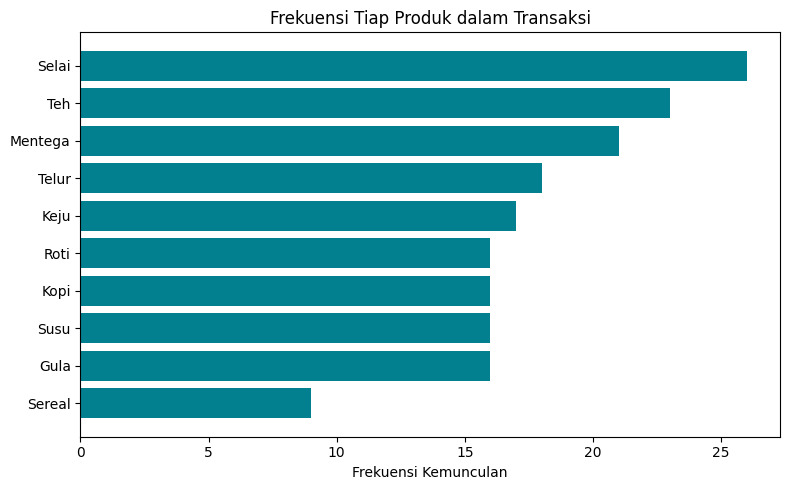

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
# Visualisasi frekuensi produk
plt.figure(figsize=(8, 5))
plt.barh(frek_df['Produk'][::-1], frek_df['Frekuensi'][::-1], color='#028090')
plt.xlabel('Frekuensi Kemunculan')
plt.title('Frekuensi Tiap Produk dalam Transaksi')
plt.tight_layout()
plt.show()

### Interpretasi EDA
- Dataset terdiri dari **50 transaksi sintetis** dengan 10 jenis produk.
- **Roti** dan **Selai** muncul lebih sering karena pola yang sengaja disuntikkan — ini yang akan coba dideteksi oleh algoritma Apriori.
- Frekuensi produk yang tinggi akan menghasilkan **Support tinggi**, menjadi kandidat kuat frequent itemset.

---
## Langkah 2: One-Hot Encoding Transaksi

Mengubah daftar transaksi menjadi tabel **one-hot encoding** menggunakan `TransactionEncoder` dari mlxtend, sehingga setiap kolom merepresentasikan satu produk dan setiap baris merepresentasikan satu transaksi (True/False).

In [5]:
# One-Hot Encoding dengan TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df_encoded = pd.DataFrame(te_ary, columns=[str(c) for c in te.columns_])

print('Shape tabel encoded:', df_encoded.shape)
print()
print('5 baris pertama:')
print(df_encoded.head().to_string())

Shape tabel encoded: (50, 10)

5 baris pertama:
    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Catatan:** Setiap baris adalah satu transaksi, setiap kolom adalah satu produk. Nilai `True` berarti produk tersebut ada di transaksi itu, `False` berarti tidak ada. Format ini adalah input yang dibutuhkan oleh fungsi `apriori()`.

---
## Langkah 3: Cari Frequent Itemset dengan Apriori

Menjalankan Apriori dengan beberapa nilai `min_support` untuk mengamati pengaruhnya terhadap jumlah itemset yang ditemukan.

In [6]:
# Bandingkan jumlah itemset pada berbagai min_support
print('Pengaruh min_support terhadap jumlah frequent itemset:')
for ms in [0.05, 0.1, 0.15, 0.2, 0.3]:
    freq = apriori(df_encoded, min_support=ms, use_colnames=True)
    print(f'  min_support={ms:.2f}: {len(freq):3d} itemset ditemukan')

Pengaruh min_support terhadap jumlah frequent itemset:
  min_support=0.05:  74 itemset ditemukan
  min_support=0.10:  44 itemset ditemukan
  min_support=0.15:  19 itemset ditemukan
  min_support=0.20:  13 itemset ditemukan
  min_support=0.30:   9 itemset ditemukan


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
# Gunakan min_support=0.1 (hasil wajar, tidak 0 tidak ratusan)
freq_items = apriori(df_encoded, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False).reset_index(drop=True)

print(f'Total frequent itemset ditemukan: {len(freq_items)}')
print()
print('Top 10 frequent itemset:')
print(freq_items.head(10).to_string(index=False))

Total frequent itemset ditemukan: 44

Top 10 frequent itemset:
 support     itemsets
    0.52      (Selai)
    0.46        (Teh)
    0.42    (Mentega)
    0.36      (Telur)
    0.34       (Keju)
    0.32       (Gula)
    0.32       (Kopi)
    0.32       (Roti)
    0.32       (Susu)
    0.24 (Selai, Teh)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

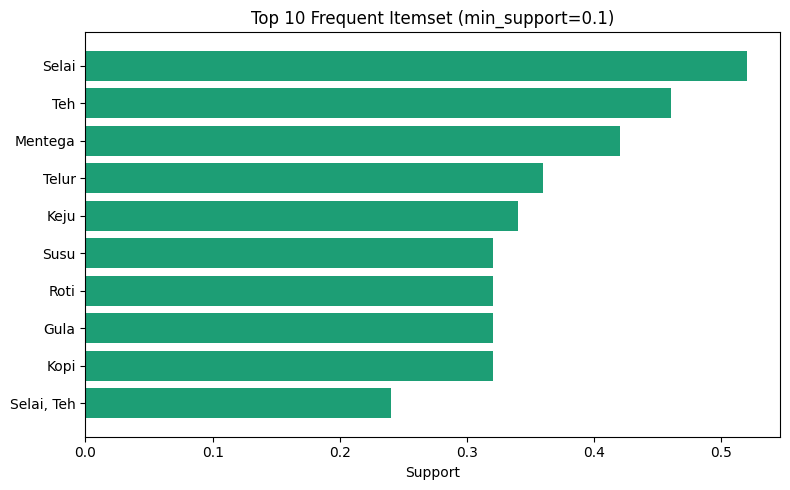

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
# Visualisasi Top 10 frequent itemset
top10 = freq_items.head(10).copy()
top10['itemsets_str'] = top10['itemsets'].apply(lambda x: ', '.join(sorted(x)))
top10 = top10.sort_values('support')

plt.figure(figsize=(8, 5))
plt.barh(top10['itemsets_str'], top10['support'], color='#1D9E75')
plt.xlabel('Support')
plt.title('Top 10 Frequent Itemset (min_support=0.1)')
plt.tight_layout()
plt.show()

### Interpretasi Frequent Itemset
- `min_support=0.1` berarti itemset harus muncul di setidaknya **10% dari total transaksi** (≥5 dari 50 transaksi).
- Semakin kecil `min_support`, semakin banyak itemset yang lolos tetapi semakin besar potensi noise.
- **Itemset tunggal** (1-itemset) dengan support tinggi adalah produk yang paling sering dibeli, sedangkan **2-itemset** seperti {Roti, Selai} menunjukkan produk yang sering dibeli bersamaan.

---
## Langkah 4: Bentuk & Saring Aturan Asosiasi

Membentuk aturan asosiasi dari frequent itemset, lalu menyaring dengan `min_confidence=0.5` dan `min_lift>1`, kemudian mengurutkan berdasarkan **Lift tertinggi**.

In [9]:
# Bentuk aturan asosiasi
rules = association_rules(freq_items, metric='confidence',
                          min_threshold=0.5,
                          num_itemsets=len(freq_items))

# Saring: hanya aturan dengan lift > 1 (korelasi positif)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Jumlah aturan asosiasi (lift > 1, confidence >= 0.5): {len(rules)}')
print()
print('Top 10 aturan berdasarkan Lift:')
print(rules[['antecedents', 'consequents',
             'support', 'confidence', 'lift']].head(10).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Jumlah aturan asosiasi (lift > 1, confidence >= 0.5): 16

Top 10 aturan berdasarkan Lift:
     antecedents consequents  support  confidence     lift
     (Keju, Teh)     (Telur)     0.12    0.857143 2.380952
(Selai, Mentega)      (Kopi)     0.10    0.625000 1.953125
    (Roti, Gula)     (Selai)     0.10    1.000000 1.923077
        (Sereal)   (Mentega)     0.14    0.777778 1.851852
    (Telur, Teh)      (Keju)     0.12    0.600000 1.764706
   (Kopi, Selai)   (Mentega)     0.10    0.714286 1.700680
   (Telur, Keju)       (Teh)     0.12    0.750000 1.630435
   (Gula, Selai)      (Roti)     0.10    0.500000 1.562500
 (Kopi, Mentega)     (Selai)     0.10    0.714286 1.373626
          (Roti)     (Selai)     0.22    0.687500 1.322115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

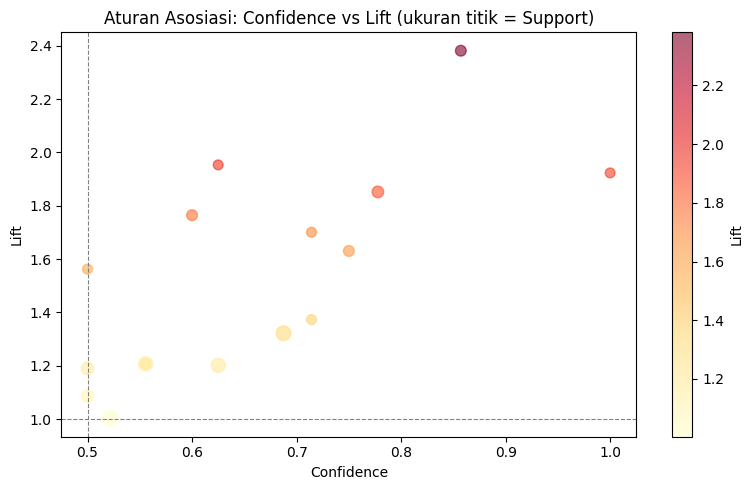

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
# Visualisasi scatter: Confidence vs Lift (ukuran = Support)
plt.figure(figsize=(8, 5))
sc = plt.scatter(rules['confidence'], rules['lift'],
                 s=rules['support'] * 500, alpha=0.6,
                 c=rules['lift'], cmap='YlOrRd')
plt.colorbar(sc, label='Lift')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Aturan Asosiasi: Confidence vs Lift (ukuran titik = Support)')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### Interpretasi Aturan Asosiasi

| Metrik | Makna | Nilai Ideal |
|---|---|---|
| **Support** | Seberapa sering itemset muncul di semua transaksi | Semakin tinggi semakin representatif |
| **Confidence** | Probabilitas membeli B jika sudah membeli A | ≥ 0.5 (50%) |
| **Lift** | Kekuatan hubungan A dan B vs kebetulan acak | > 1 (korelasi positif) |

- Aturan dengan **Lift tertinggi** adalah yang paling bermakna secara bisnis — A dan B benar-benar sering dibeli bersama, bukan karena kebetulan.
- Aturan **Roti → Selai** (jika ada) merupakan pola yang sengaja disuntikkan di Langkah 1 dan seharusnya muncul dengan Lift tinggi.
- **Confidence tinggi tapi Lift rendah** bisa terjadi jika item B memang sangat populer (dibeli hampir semua orang), bukan karena hubungan dengan A.

---
## Langkah 5: Rekomender Sederhana dengan Content-Based Filtering

Membangun katalog produk dengan kategori, lalu membuat rekomendasi produk serupa menggunakan **cosine similarity** atas fitur kategori (one-hot encoding).

In [11]:
# Buat katalog produk dengan kategori
katalog = pd.DataFrame({
    'produk'  : produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy'],
    'harga'   : [8000, 15000, 12000, 25000, 20000,
                 35000, 30000, 10000, 18000, 22000]
})

print('Katalog produk:')
print(katalog.to_string(index=False))

Katalog produk:
 produk kategori  harga
   Roti   Bakery   8000
  Selai   Bakery  15000
   Susu    Dairy  12000
 Sereal   Bakery  25000
  Telur    Dairy  20000
   Keju    Dairy  35000
   Kopi  Minuman  30000
   Gula    Bumbu  10000
    Teh  Minuman  18000
Mentega    Dairy  22000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
# One-hot encoding kategori sebagai fitur konten
fitur = pd.get_dummies(katalog['kategori'])

print('Fitur kategori (one-hot):')
print(fitur.to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Fitur kategori (one-hot):
   Bakery  Bumbu  Dairy  Minuman
0    True  False  False    False
1    True  False  False    False
2   False  False   True    False
3    True  False  False    False
4   False  False   True    False
5   False  False   True    False
6   False  False  False     True
7   False   True  False    False
8   False  False  False     True
9   False  False   True    False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
# Hitung cosine similarity antar produk
sim_matrix = cosine_similarity(fitur)
sim_df = pd.DataFrame(sim_matrix,
                      index=katalog['produk'],
                      columns=katalog['produk'])

print('Similarity matrix antar produk:')
print(sim_df.round(2).to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Similarity matrix antar produk:
produk   Roti  Selai  Susu  Sereal  Telur  Keju  Kopi  Gula  Teh  Mentega
produk                                                                   
Roti      1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Selai     1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Susu      0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
Sereal    1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Telur     0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
Keju      0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
Kopi      0.0    0.0   0.0     0.0    0.0   0.0   1.0   0.0  1.0      0.0
Gula      0.0    0.0   0.0     0.0    0.0   0.0   0.0   1.0  0.0      0.0
Teh       0.0    0.0   0.0     0.0    0.0   0.0   1.0   0.0  1.0      0.0
Mentega   0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [14]:
# Fungsi rekomendasi Content-Based
def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    hasil = katalog.iloc[[i for i, _ in skor]][['produk', 'kategori', 'harga']].copy()
    hasil['similarity'] = [round(s, 3) for _, s in skor]
    return hasil

# Uji rekomendasi untuk beberapa produk
for p in ['Roti', 'Susu', 'Kopi']:
    print(f'Rekomendasi serupa dengan "{p}":')
    print(rekomendasi_serupa(p).to_string(index=False))
    print()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Rekomendasi serupa dengan "Roti":
produk kategori  harga  similarity
 Selai   Bakery  15000         1.0
Sereal   Bakery  25000         1.0
  Susu    Dairy  12000         0.0

Rekomendasi serupa dengan "Susu":
 produk kategori  harga  similarity
  Telur    Dairy  20000         1.0
   Keju    Dairy  35000         1.0
Mentega    Dairy  22000         1.0

Rekomendasi serupa dengan "Kopi":
produk kategori  harga  similarity
   Teh  Minuman  18000         1.0
  Roti   Bakery   8000         0.0
 Selai   Bakery  15000         0.0



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Interpretasi Content-Based Filtering
- Produk direkomendasikan berdasarkan **kemiripan kategori** — Roti (Bakery) direkomendasikan bersama Selai dan Sereal (keduanya Bakery).
- **Cosine similarity = 1.0** berarti dua produk berada dalam kategori yang sama persis.
- **Cosine similarity = 0.0** berarti dua produk tidak memiliki kategori yang sama.
- Pendekatan ini tidak membutuhkan histori interaksi pengguna — cocok untuk kasus **cold start** (produk atau pengguna baru).

---
## Langkah 6: Bandingkan Kedua Pendekatan

Membandingkan rekomendasi dari **aturan asosiasi** (Langkah 4) dengan rekomendasi **Content-Based Filtering** (Langkah 5) untuk produk yang sama.

In [15]:
# Produk yang dibandingkan
produk_target = 'Roti'

print(f'=== Rekomendasi untuk produk: "{produk_target}" ===')
print()

# Pendekatan 1: Association Rules
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)]
print('Dari Association Rules (lift > 1, confidence >= 0.5):')
if len(rules_terkait) > 0:
    print(rules_terkait[['consequents', 'support', 'confidence', 'lift']]          .head(5).to_string(index=False))
else:
    print('  (Tidak ada aturan yang ditemukan untuk produk ini)')

print()

# Pendekatan 2: Content-Based Filtering
print('Dari Content-Based Filtering (cosine similarity kategori):')
print(rekomendasi_serupa(produk_target).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Rekomendasi untuk produk: "Roti" ===

Dari Association Rules (lift > 1, confidence >= 0.5):
consequents  support  confidence     lift
    (Selai)     0.10      1.0000 1.923077
    (Selai)     0.22      0.6875 1.322115

Dari Content-Based Filtering (cosine similarity kategori):
produk kategori  harga  similarity
 Selai   Bakery  15000         1.0
Sereal   Bakery  25000         1.0
  Susu    Dairy  12000         0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [16]:
# Evaluasi Precision@K untuk Content-Based Filtering
# Asumsikan item_relevan = produk yang sering dibeli bersama (dari rules)
def precision_at_k(rekomendasi_list, item_relevan, k=3):
    top_k = rekomendasi_list[:k]
    relevan_ditemukan = len(set(top_k) & set(item_relevan))
    return relevan_ditemukan / k

# Item relevan: produk yang muncul di aturan asosiasi terkait Roti
item_relevan_roti = []
for _, row in rules_terkait.iterrows():
    item_relevan_roti.extend(list(row['consequents']))
item_relevan_roti = list(set(item_relevan_roti))

# Rekomendasi Content-Based
rek_cb = rekomendasi_serupa(produk_target, top_n=5)['produk'].tolist()

p_at_k = precision_at_k(rek_cb, item_relevan_roti, k=3)
print(f'Item relevan (dari association rules) : {item_relevan_roti}')
print(f'Rekomendasi Content-Based (Top-3)     : {rek_cb[:3]}')
print(f'Precision@3                            : {p_at_k:.3f}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Item relevan (dari association rules) : ['Selai']
Rekomendasi Content-Based (Top-3)     : ['Selai', 'Sereal', 'Susu']
Precision@3                            : 0.333


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Perbandingan Kedua Pendekatan

| Aspek | Association Rules (Apriori) | Content-Based Filtering |
|---|---|---|
| **Dasar rekomendasi** | Pola pembelian bersama antar pelanggan | Kemiripan atribut/kategori produk |
| **Data yang dibutuhkan** | Histori transaksi | Atribut/metadata produk |
| **Cold start** | ❌ Butuh histori yang cukup | ✅ Bisa langsung pakai metadata |
| **Contoh hasil "Roti"** | Selai (pola transaksi) | Sereal, Selai (sesama Bakery) |
| **Kapan digunakan** | Rekomendasi cross-sell, bundling produk | Produk baru, pengguna baru |

- **Association Rules** menemukan rekomendasi berdasarkan perilaku nyata pembeli — lebih kontekstual secara bisnis.
- **Content-Based Filtering** menemukan rekomendasi berdasarkan kemiripan kategori — lebih cocok saat histori transaksi belum tersedia.
- **Pendekatan hybrid** (menggabungkan keduanya) menghasilkan rekomendasi yang lebih komprehensif, seperti yang dilakukan Netflix, Spotify, dan Amazon.

## Kesimpulan

Pada pertemuan ini, saya mempelajari dua teknik Unsupervised Learning yang saling melengkapi: **Association Rule Mining** dengan algoritma Apriori dan **Content-Based Filtering** untuk sistem rekomendasi. Algoritma Apriori berhasil menemukan pola pembelian tersembunyi pada dataset sintetis — khususnya aturan Roti → Selai yang sengaja disuntikkan — dengan menggunakan tiga metrik kunci: Support (frekuensi), Confidence (kekuatan aturan), dan Lift (korelasi sejati yang menghilangkan efek popularitas). Perbandingan kedua pendekatan rekomendasi menunjukkan bahwa Association Rules lebih unggul ketika histori transaksi tersedia karena mencerminkan perilaku nyata pelanggan, sementara Content-Based Filtering lebih andal pada situasi cold start karena hanya mengandalkan atribut produk. Dalam praktik nyata, sistem rekomendasi modern menggunakan pendekatan hybrid yang menggabungkan keunggulan keduanya untuk mengatasi kelemahan masing-masing.